# 07 -- architecture v2 -- LSTM

Данные беру из [06_LSTM_Data_Preparation.ipynb](./06_LSTM_Data_Preparation.ipynb), static-признаки -- из [05_Data-Modeling.ipynb](./05_Data-Modeling.ipynb).

Использую две отдельные hybrid-модели с одинаковой архитектурой и разными весами:

1. **classifier** учится на всех пользователях и предсказывает $P(GMV > 0)$;
2. **regressor** учится только на $GMV > 0$ и предсказывает $\log(1 + GMV)$.

Обе модели получают весь вход: `90 x 40` sequence-признаков через BiLSTM + 241 static-признак через MLP.

Финальный прогноз считаю сразу в log-space:

$$
\log(1 + \hat y)
=
P(GMV > 0)
\cdot
\widehat{\log(1 + GMV \mid GMV > 0)}.
$$

Последний размеченный cutoff оставляю под validation для early stopping и postprocessing. Потом переобучаю обе модели на всех размеченных cutoff и делаю submission.

В этой версии меняю только архитектуру. Data pipeline, loss, optimizer, early stopping и финальный inference оставляю без изменений.


## Loss

Метрика -- RMSLE:

$$
RMSLE =
\sqrt{
\frac{1}{n}
\sum_i
\left(
\log(1 + y_i) - \log(1 + \hat y_i)
\right)^2
}.
$$

Regressor сразу предсказывает $\log(1 + GMV)$, поэтому `MSE(pred_log, log1p(y))` -- это MSLE, т.е. квадрат RMSLE. `sqrt` в loss не нужен: минимум от этого не меняется.

Обычный MSE по рублям здесь хуже соответствует leaderboard-метрике и сильнее тянется за крупными GMV.

Classifier решает бинарную задачу `GMV > 0`, для него использую `BCEWithLogitsLoss`.

## Почему меняю архитектуру

По learning curves текущая конфигурация быстро выходит на плато:

- classifier показывает лучший validation loss почти сразу;
- regressor резко улучшается в первые эпохи, а дальше почти не меняется;
- validation дальше в основном колеблется около одного уровня.

Поэтому не просто увеличиваю число эпох. Меняю representation сети:

- dropout уменьшаю с `0.30` до `0.15`, чтобы не слишком сильно вырезать сигнал;
- добавляю `Conv1d` перед BiLSTM, чтобы отдельно ловить локальные паттерны на соседних днях;
- увеличиваю projection sequence `40 -> 128`;
- оставляю `2-layer BiLSTM`, но делаю hidden size `96`: после двунаправленности получаю 192 признака на день;
- sequence pooling оставляю `last + mean + max`;
- static MLP делаю шире и глубже: `241 -> 384 -> 192`;
- fusion делаю `384 -> 256 -> 128 -> 1`.

Для hidden layers оставляю `GELU`. Здесь не хочу одновременно менять архитектуру и все activation functions: GELU уже хорошо работает с нормализованными dense representation. ReLU в конце тоже не нужен -- выход classifier должен быть logit, а выход regressor может быть отрицательным до объединения с `clamp`.


## Настройки

Не подбираю гиперпараметры оптимизатора:

- `AdamW` со значениями по умолчанию;
- максимум 50 эпох;
- early stopping с `patience=4`;
- `random_state=42`.

Все cutoff кроме последнего -- train, последний -- validation.

После early stopping отдельно на всех данных модель не переобучаю. Для этого эксперимента использую именно лучшие веса, найденные на validation.


In [1]:
from copy import deepcopy
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, Dataset


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "lstm" / "meta.json").exists():
            return path
    raise FileNotFoundError("Сначала запустите 06_LSTM_Data_Preparation.ipynb")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lstm"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
SUBMISSION_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / "meta.json", encoding="utf-8") as f:
    META = json.load(f)

LABELED_CUTOFFS = META["labeled_cutoffs"]
INFERENCE_CUTOFF = META["inference_cutoff"]
BASE_SEQUENCE_FEATURES = META["base_sequence_features"]
CALENDAR_FEATURES = META["calendar_sequence_features"]
STATIC_FEATURES = META["static_features"]
STATIC_LOG_FEATURES = META["static_log_copy_features"]

BASE_INDEX = {name: i for i, name in enumerate(BASE_SEQUENCE_FEATURES)}
STATIC_LOG_INDICES = [STATIC_FEATURES.index(name) for name in STATIC_LOG_FEATURES]

TRAIN_CUTOFFS = LABELED_CUTOFFS[:-1]
VAL_CUTOFF = LABELED_CUTOFFS[-1]

BATCH_SIZE = 1024
MAX_EPOCHS = 50
PATIENCE = 4
RANDOM_STATE = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0


def set_seed():
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)


set_seed()
print("device:", DEVICE)
print("train cutoffs:", len(TRAIN_CUTOFFS))
print("validation:", VAL_CUTOFF)

device: mps
train cutoffs: 9
validation: 2026-01-14


## Dataset

Для обеих моделей использую один объект: 90-дневная последовательность + static snapshot.

Regressor просто получает только строки с `y > 0`.

In [2]:
class HybridDataset(Dataset):
    def __init__(self, cutoff, with_target=True, positive_only=False):
        path = DATA_DIR / cutoff
        self.X = np.load(path / "X.npy", mmap_mode="r")
        self.static = np.load(path / "static.npy", mmap_mode="r")
        self.calendar = np.load(path / "calendar.npy", mmap_mode="r").astype(np.float32)
        self.users = np.load(path / "user_id.npy", mmap_mode="r")
        self.y = np.load(path / "y.npy", mmap_mode="r") if with_target else None
        self.indices = np.flatnonzero(self.y > 0) if positive_only else None

    def __len__(self):
        return len(self.X) if self.indices is None else len(self.indices)

    def __getitem__(self, i):
        j = i if self.indices is None else int(self.indices[i])

        sequence = np.concatenate([
            np.array(self.X[j], dtype=np.float32),
            self.calendar,
        ], axis=1)

        sequence = torch.from_numpy(sequence)
        static = torch.from_numpy(np.array(self.static[j], dtype=np.float32))

        if self.y is None:
            return sequence, static

        return sequence, static, torch.tensor(float(self.y[j]), dtype=torch.float32)


def make_loader(cutoffs, shuffle=False, with_target=True, positive_only=False):
    if isinstance(cutoffs, str):
        cutoffs = [cutoffs]

    dataset = ConcatDataset([
        HybridDataset(cutoff, with_target, positive_only)
        for cutoff in cutoffs
    ])

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=shuffle,
    )

## Динамические признаки

К 13 базовым каналам и 6 календарным добавляю 21 производный признак:

- события `has_*`;
- conversion ratios;
- rolling mean за 7/30 дней;
- rolling activity rate за 7/30 дней;
- первые разности.

Получается 40 признаков на каждый из 90 дней.

Rolling считаю только по текущему и предыдущим дням. Все окно находится до target, leakage здесь нет.

In [3]:
def causal_mean(values, window):
    values = F.pad(values.unsqueeze(1), (window - 1, 0))
    return F.avg_pool1d(values, window, stride=1).squeeze(1)


def first_difference(values):
    return F.pad(values[:, 1:] - values[:, :-1], (1, 0))


def safe_ratio(numerator, denominator, max_value=5.0):
    ratio = numerator / denominator.clamp_min(1e-3)
    ratio = torch.where(denominator > 0, ratio, torch.zeros_like(ratio))
    return ratio.clamp(0, max_value)


def make_sequence_features(x):
    searches_log = x[..., BASE_INDEX["searches"]]
    search_to_cart_log = x[..., BASE_INDEX["search_to_cart"]]
    search_to_ord_log = x[..., BASE_INDEX["search_to_ord"]]
    cat_to_cart_log = x[..., BASE_INDEX["cat_to_cart"]]
    cat_to_ord_log = x[..., BASE_INDEX["cat_to_ord"]]
    to_cart_log = x[..., BASE_INDEX["to_cart"]]
    to_ord_log = x[..., BASE_INDEX["to_ord"]]
    gmv_search_log = x[..., BASE_INDEX["gmv_search"]]
    gmv_log = x[..., BASE_INDEX["gmv"]]
    active = x[..., BASE_INDEX["active"]]

    searches = torch.expm1(searches_log).clamp_min(0)
    search_to_cart = torch.expm1(search_to_cart_log).clamp_min(0)
    search_to_ord = torch.expm1(search_to_ord_log).clamp_min(0)
    cat_to_cart = torch.expm1(cat_to_cart_log).clamp_min(0)
    cat_to_ord = torch.expm1(cat_to_ord_log).clamp_min(0)
    to_cart = torch.expm1(to_cart_log).clamp_min(0)
    to_ord = torch.expm1(to_ord_log).clamp_min(0)
    gmv_search = torch.expm1(gmv_search_log).clamp_min(0)
    gmv = torch.expm1(gmv_log).clamp_min(0)

    derived = [
        (search_to_cart > 0).float(),
        (search_to_ord > 0).float(),
        (cat_to_cart > 0).float(),
        (cat_to_ord > 0).float(),
        safe_ratio(search_to_cart, searches),
        safe_ratio(search_to_ord, searches),
        safe_ratio(to_ord, to_cart),
        safe_ratio(gmv_search, gmv, 1.5),
    ]

    for values in [searches_log, to_cart_log, to_ord_log, gmv_log]:
        derived += [causal_mean(values, 7), causal_mean(values, 30)]

    derived += [
        causal_mean(active, 7),
        causal_mean(active, 30),
        first_difference(searches_log),
        first_difference(to_ord_log),
        first_difference(gmv_log),
    ]

    return torch.cat([x, torch.stack(derived, dim=-1)], dim=-1)


SEQUENCE_INPUT_SIZE = len(BASE_SEQUENCE_FEATURES) + len(CALENDAR_FEATURES) + 21
print("sequence features:", SEQUENCE_INPUT_SIZE)

sequence features: 40


## Static preprocessing

Использую все 95 static-признаков из [06_LSTM_Data_Preparation.ipynb](./06_LSTM_Data_Preparation.ipynb).

Добавляю:

- `log1p`-копии 51 heavy-tail признака;
- missing mask для всех 95 исходных признаков.

Получается 241 static-признак.

Среднее и std считаю только по train-cutoff. Validation в статистику не попадает; при финальном обучении статистика считается по всем размеченным cutoff.

In [4]:
STATIC_INPUT_SIZE = 2 * len(STATIC_FEATURES) + len(STATIC_LOG_INDICES)


def augment_static_numpy(raw):
    raw = np.asarray(raw, dtype=np.float32)
    source = raw[:, STATIC_LOG_INDICES]

    logs = np.where(
        np.isfinite(source),
        np.log1p(np.clip(source, 0, None)),
        np.nan,
    ).astype(np.float32)

    missing = (~np.isfinite(raw)).astype(np.float32)
    return np.concatenate([raw, logs, missing], axis=1)


def fit_static_stats(cutoffs, chunk_size=65_536):
    sums = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    sums_sq = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    counts = np.zeros(STATIC_INPUT_SIZE, dtype=np.int64)

    for cutoff in cutoffs:
        raw = np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r")

        for start in range(0, len(raw), chunk_size):
            block = augment_static_numpy(raw[start:start + chunk_size])
            finite = np.isfinite(block)
            safe = np.where(finite, block, 0.0).astype(np.float64)

            sums += safe.sum(axis=0)
            sums_sq += (safe * safe).sum(axis=0)
            counts += finite.sum(axis=0)

    counts = np.maximum(counts, 1)
    mean = sums / counts
    std = np.sqrt(np.maximum(sums_sq / counts - mean * mean, 1e-6))

    return (
        torch.tensor(mean, dtype=torch.float32),
        torch.tensor(std, dtype=torch.float32),
    )


def normalize_static(raw, stats):
    source = raw[:, STATIC_LOG_INDICES]
    logs = torch.where(
        torch.isfinite(source),
        torch.log1p(source.clamp_min(0)),
        torch.nan,
    )

    x = torch.cat([
        raw,
        logs,
        (~torch.isfinite(raw)).float(),
    ], dim=1)

    mean, std = stats
    mean = mean.to(raw.device)
    std = std.to(raw.device)

    x = torch.where(torch.isfinite(x), x, mean)
    return (x - mean) / std


print("static features:", STATIC_INPUT_SIZE)

static features: 241


## Архитектура

Classifier и regressor -- **две отдельные модели**, веса между ними не шарятся.

Sequence-ветка:

```text
40 -> BatchNorm -> Linear(96) -> 2-layer BiLSTM(128)
   -> last hidden + mean pooling + max pooling
   -> 256
```

Static-ветка:

```text
241 -> BatchNorm -> 256 -> 128
```

Дальше объединяю обе ветки:

```text
256 + 128 -> 256 -> 64 -> 1
```

Backbone у моделей одинаковый, но обучаются они независимо: classifier на BCE по всем пользователям, regressor на MSLE только по `y > 0`.

In [5]:
class HybridLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.sequence_bn = nn.BatchNorm1d(SEQUENCE_INPUT_SIZE)
        self.sequence_projection = nn.Sequential(
            nn.Linear(SEQUENCE_INPUT_SIZE, 128),
            nn.GELU(),
        )

        self.conv = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.GELU(),
        )

        self.lstm = nn.LSTM(
            128,
            96,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.15,
        )

        self.sequence_head = nn.Sequential(
            nn.LayerNorm(96 * 6),
            nn.Linear(96 * 6, 256),
            nn.GELU(),
            nn.Dropout(0.15),
        )

        self.static_head = nn.Sequential(
            nn.BatchNorm1d(STATIC_INPUT_SIZE),
            nn.Linear(STATIC_INPUT_SIZE, 384),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(384, 192),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.fusion = nn.Sequential(
            nn.Linear(448, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(128, 1),
        )

    def forward(self, sequence, static):
        sequence = make_sequence_features(sequence)
        sequence = self.sequence_bn(sequence.transpose(1, 2)).transpose(1, 2)
        sequence = self.sequence_projection(sequence)
        sequence = self.conv(sequence.transpose(1, 2)).transpose(1, 2)

        output, (hidden, _) = self.lstm(sequence)

        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        sequence_repr = self.sequence_head(torch.cat([
            last_hidden,
            output.mean(dim=1),
            output.amax(dim=1),
        ], dim=1))

        static_repr = self.static_head(static)
        return self.fusion(torch.cat([sequence_repr, static_repr], dim=1)).squeeze(1)


class PurchaseClassifier(HybridLSTM):
    pass


class GMVRegressor(HybridLSTM):
    pass


print("classifier parameters:", f"{sum(p.numel() for p in PurchaseClassifier().parameters()):,}")
print("regressor parameters:", f"{sum(p.numel() for p in GMVRegressor().parameters()):,}")

classifier parameters: 915,571
regressor parameters: 915,571


## Early stopping + learning curves

Ставлю `MAX_EPOCHS=50`, но сохраняю веса с минимальным validation loss и останавливаюсь после 6 эпох без улучшения.

- classifier: BCE;
- regressor: `MSE(pred_log, log1p(y))`, т.е. MSLE на положительных target.

После каждого обучения строю train/validation learning curve.

In [6]:
def model_loss(output, y, task):
    if task == "classifier":
        return F.binary_cross_entropy_with_logits(output, (y > 0).float())

    # MSE по log1p(y) = MSLE; sqrt из RMSLE минимум не меняет.
    return F.mse_loss(output, torch.log1p(y))

In [7]:
def run_epoch(model, loader, task, static_stats, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_n = 0

    for sequence, static, y in loader:
        sequence = sequence.to(DEVICE)
        static = normalize_static(static.to(DEVICE), static_stats)
        y = y.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            output = model(sequence, static)
            loss = model_loss(output, y, task)

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * len(y)
        total_n += len(y)

    return total_loss / total_n


def fit_with_early_stopping(model_class, task, train_cutoffs, val_cutoff, static_stats):
    set_seed()

    train_loader = make_loader(
        train_cutoffs,
        shuffle=True,
        positive_only=task == "regressor",
    )
    val_loader = make_loader(
        val_cutoff,
        positive_only=task == "regressor",
    )

    model = model_class().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters())

    history = {"train": [], "val": []}
    best_loss = float("inf")
    best_epoch = 0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, task, static_stats, optimizer)
        val_loss = run_epoch(model, val_loader, task, static_stats)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        print(
            f"{task:10s} | epoch {epoch:02d} | "
            f"train={train_loss:.5f} | val={val_loss:.5f}"
        )

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, history

In [8]:
def plot_history(history, title):
    epochs = np.arange(1, len(history["train"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train"], label="train")
    plt.plot(epochs, history["val"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

## Classifier

In [9]:
static_stats = fit_static_stats(TRAIN_CUTOFFS)

classifier, classifier_best_epoch, classifier_history = fit_with_early_stopping(
    PurchaseClassifier,
    "classifier",
    TRAIN_CUTOFFS,
    VAL_CUTOFF,
    static_stats,
)

print("best classifier epoch:", classifier_best_epoch)

classifier | epoch 01 | train=0.47748 | val=0.47481
classifier | epoch 02 | train=0.47550 | val=0.47155
classifier | epoch 03 | train=0.47502 | val=0.46870
classifier | epoch 04 | train=0.47463 | val=0.47089
classifier | epoch 05 | train=0.47417 | val=0.46995
classifier | epoch 06 | train=0.47391 | val=0.47389
classifier | epoch 07 | train=0.47369 | val=0.47139
best classifier epoch: 3


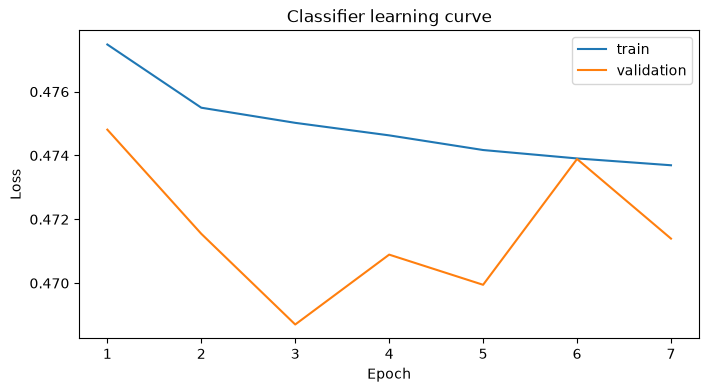

In [10]:
plot_history(classifier_history, "Classifier learning curve")

## Regressor

Train и validation для regressor содержат только `y > 0`.

In [11]:
regressor, regressor_best_epoch, regressor_history = fit_with_early_stopping(
    GMVRegressor,
    "regressor",
    TRAIN_CUTOFFS,
    VAL_CUTOFF,
    static_stats,
)

print("best regressor epoch:", regressor_best_epoch)

regressor  | epoch 01 | train=1.43006 | val=1.30129
regressor  | epoch 02 | train=1.28342 | val=1.25968
regressor  | epoch 03 | train=1.27774 | val=1.25596
regressor  | epoch 04 | train=1.27480 | val=1.24954
regressor  | epoch 05 | train=1.27107 | val=1.25382
regressor  | epoch 06 | train=1.26829 | val=1.25789
regressor  | epoch 07 | train=1.26798 | val=1.30125
regressor  | epoch 08 | train=1.26716 | val=1.25578
best regressor epoch: 4


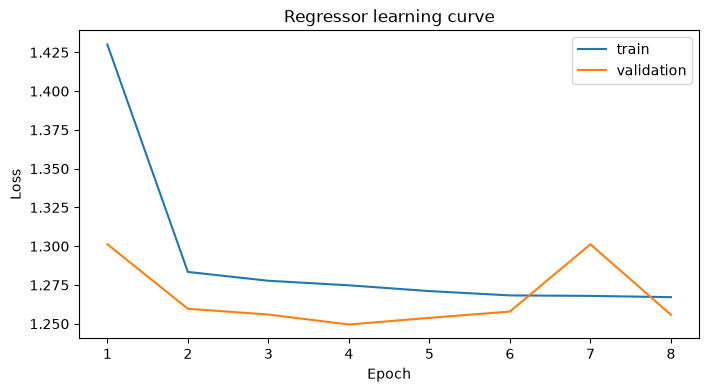

In [12]:
plot_history(regressor_history, "Regressor learning curve")

## Предсказание

Classifier возвращает вероятность $p=P(GMV>0)$, regressor -- conditional `log1p(GMV)`.

Склеиваю **до `expm1`**:

```text
p = sigmoid(classifier_logit)
pred_log = p * regressor_log
prediction = expm1(pred_log)
```

Так итоговый prediction остается согласован с RMSLE.

In [13]:
@torch.no_grad()
def predict_raw(model, cutoff, static_stats, with_target=True):
    dataset = HybridDataset(cutoff, with_target=with_target)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )

    model.eval()
    outputs = []
    targets = []

    for batch in loader:
        if with_target:
            sequence, static, y = batch
            targets.append(y.numpy())
        else:
            sequence, static = batch

        sequence = sequence.to(DEVICE)
        static = normalize_static(static.to(DEVICE), static_stats)
        outputs.append(model(sequence, static).cpu().numpy())

    y = np.concatenate(targets) if with_target else None
    return np.asarray(dataset.users), np.concatenate(outputs), y


def make_prediction(classifier_logits, regressor_log):
    probability = 1.0 / (1.0 + np.exp(-np.clip(classifier_logits, -30, 30)))
    pred_log = probability * np.clip(regressor_log, 0, None)
    return probability, pred_log, np.expm1(pred_log)


def rmsle_from_log(y, pred_log):
    return float(np.sqrt(np.mean((pred_log - np.log1p(y)) ** 2)))


_, val_logits, y_val = predict_raw(classifier, VAL_CUTOFF, static_stats)
_, val_reg_log, _ = predict_raw(regressor, VAL_CUTOFF, static_stats)

val_probability, val_pred_log, val_pred = make_prediction(
    val_logits,
    val_reg_log,
)

print("base validation RMSLE:", f"{rmsle_from_log(y_val, val_pred_log):.6f}")
print("true zeros:", f"{(y_val == 0).mean():.2%}")

base validation RMSLE: 1.677812
true zeros: 45.93%


## Финальное обучение

Validation выбрал:

- число эпох classifier;
- число эпох regressor;
- `fraction` и `scale`.

Теперь обучаю две новые независимые модели на **всех размеченных cutoff** уже фиксированное число эпох.

In [14]:
def fit_fixed_epochs(model_class, task, cutoffs, static_stats, epochs):
    set_seed()

    loader = make_loader(
        cutoffs,
        shuffle=True,
        positive_only=task == "regressor",
    )

    model = model_class().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters()
    )

    for epoch in range(1, epochs + 1):
        loss = run_epoch(model, loader, task, static_stats, optimizer)
        print(f"{task:10s} | epoch {epoch:02d}/{epochs:02d} | loss={loss:.5f}")

    return model


final_static_stats = fit_static_stats(LABELED_CUTOFFS)

final_classifier = fit_fixed_epochs(
    PurchaseClassifier,
    "classifier",
    LABELED_CUTOFFS,
    final_static_stats,
    classifier_best_epoch,
)

final_regressor = fit_fixed_epochs(
    GMVRegressor,
    "regressor",
    LABELED_CUTOFFS,
    final_static_stats,
    regressor_best_epoch,
)

classifier | epoch 01/03 | loss=0.47678
classifier | epoch 02/03 | loss=0.47489
classifier | epoch 03/03 | loss=0.47433
regressor  | epoch 01/04 | loss=1.41293
regressor  | epoch 02/04 | loss=1.27689
regressor  | epoch 03/04 | loss=1.27260
regressor  | epoch 04/04 | loss=1.26938


## Submission

Использую лучшие веса, сохраненные early stopping, и сразу делаю prediction для inference cutoff.


In [15]:
user_ids, inference_logits, _ = predict_raw(
    classifier,
    INFERENCE_CUTOFF,
    static_stats,
    with_target=False,
)
_, inference_reg_log, _ = predict_raw(
    regressor,
    INFERENCE_CUTOFF,
    static_stats,
    with_target=False,
)

_, _, pred = make_prediction(
    inference_logits,
    inference_reg_log,
)

submission = pd.read_csv(PROJECT_ROOT / "data" / "sample_submit.csv")
submission["predict"] = submission["user_id"].map(
    pd.Series(pred, index=user_ids)
).clip(lower=0)

out_path = SUBMISSION_DIR / "lstm_architecture_v2.csv"
submission.to_csv(out_path, index=False)

print("saved:", out_path)
print("exact zeros:", f"{(submission['predict'] == 0).mean():.2%}")
submission.head()


saved: /Users/pinta/Dev/E-CUP-2026/submissions/lstm_architecture_v2.csv
exact zeros: 0.00%


,user_id,predict
0,2,2.522461
1,7,90.581390
2,15,7.227880
3,18,159.582657
4,23,0.540378


> 1.6735082186, откат...